In [12]:
import json
import time
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

INPUT_DIR = Path("../runs/processed/full_split")
RESULTS_DIR = Path("../runs/results/random_forest_full")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input dir:", INPUT_DIR)
print("Results dir:", RESULTS_DIR)

Input dir: ..\runs\processed\full_split
Results dir: ..\runs\results\random_forest_full


In [13]:
#데이터 로드
X_train = pd.read_csv(INPUT_DIR / "X_train.csv")
X_test = pd.read_csv(INPUT_DIR / "X_test.csv")

y_train = pd.read_csv(INPUT_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(INPUT_DIR / "y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1764462, 52)
X_test: (378113, 52)
y_train: (1764462,)
y_test: (378113,)


In [14]:
#평가 함수 정의
def evaluate_binary_classification(y_true, y_pred, model_name, dataset_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    result = {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision_attack": precision,
        "recall_attack": recall,
        "f1_attack": f1,
        "fpr": fpr,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }
    
    return result, cm

In [15]:
#하이퍼 파라미터 설정
best_rf_params = {
    "n_estimators": 70,
    "max_depth": 35,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

print("Final Random Forest parameters")
print(best_rf_params)

with open(RESULTS_DIR / "rf_full_best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_rf_params, f, indent=4, ensure_ascii=False)

print("Saved:", RESULTS_DIR / "rf_full_best_params.json")

Final Random Forest parameters
{'n_estimators': 70, 'max_depth': 35, 'min_samples_split': 5, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Saved: ..\runs\results\random_forest_full\rf_full_best_params.json


In [16]:
#Random Forest 학습 
rf_full_model = RandomForestClassifier(**best_rf_params)

start_time = time.time()

rf_full_model.fit(X_train, y_train)

train_time = time.time() - start_time

print("Full dataset Random Forest training completed.")
print("Training time(sec):", round(train_time, 4))

Full dataset Random Forest training completed.
Training time(sec): 89.2673


In [17]:
#test set으로 평가
start_time = time.time()

y_test_pred = rf_full_model.predict(X_test)

test_inference_time = time.time() - start_time

rf_full_test_result, rf_full_test_cm = evaluate_binary_classification(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name="Random Forest Full",
    dataset_name="full_test"
)

rf_full_test_result["train_time_sec"] = train_time
rf_full_test_result["test_inference_time_sec"] = test_inference_time

rf_full_test_results = pd.DataFrame([rf_full_test_result])

print("\nClassification Report")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Normal Traffic", "Attack Traffic"],
    digits=4,
    zero_division=0
))


Classification Report
                precision    recall  f1-score   support

Normal Traffic     0.9993    0.9992    0.9993    314259
Attack Traffic     0.9961    0.9966    0.9964     63854

      accuracy                         0.9988    378113
     macro avg     0.9977    0.9979    0.9978    378113
  weighted avg     0.9988    0.9988    0.9988    378113



In [18]:
#성능 표
rf_full_test_table = rf_full_test_results.copy()

rf_full_test_table = rf_full_test_table[[
    "model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

rf_full_test_table.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

styled_rf_full_test_table = (
    rf_full_test_table.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "FPR": "{:.4f}"
    })
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#E6E6E6"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "12pt"),
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto")
            ]
        }
    ])
)

display(styled_rf_full_test_table)

,Model,Accuracy,Precision,Recall,F1-score,FPR,FP,FN
0,Random Forest Full,0.9988,0.9961,0.9966,0.9964,0.0008,249,216


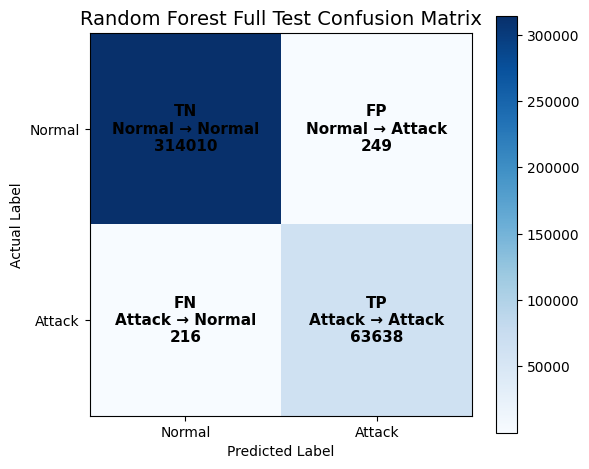

Saved: ..\runs\results\random_forest_full\rf_full_test_confusion_matrix.png


In [19]:
#confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(rf_full_test_cm, cmap="Blues")

ax.set_title("Random Forest Full Test Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Attack"])
ax.set_yticklabels(["Normal", "Attack"])

labels = [
    ["TN\nNormal → Normal", "FP\nNormal → Attack"],
    ["FN\nAttack → Normal", "TP\nAttack → Attack"]
]

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{labels[i][j]}\n{rf_full_test_cm[i, j]}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "rf_full_test_confusion_matrix.png", dpi=300)
plt.show()

print("Saved:", RESULTS_DIR / "rf_full_test_confusion_matrix.png")

In [20]:
#Feature Importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_full_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

top_feature_importance = feature_importance.head(15)

display(top_feature_importance)

feature_importance.to_csv(
    RESULTS_DIR / "rf_full_feature_importance.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "rf_full_feature_importance.csv")

,feature,importance
0,Packet Length Variance,0.087420
1,Bwd Packet Length Std,0.078394
2,Average Packet Size,0.077473
3,Packet Length Std,0.061632
4,Destination Port,0.058078
5,Bwd Packet Length Mean,0.056715
6,Max Packet Length,0.051328
7,Packet Length Mean,0.043519
8,Fwd Packet Length Mean,0.040535
9,Init_Win_bytes_forward,0.036523


Saved: ..\runs\results\random_forest_full\rf_full_feature_importance.csv


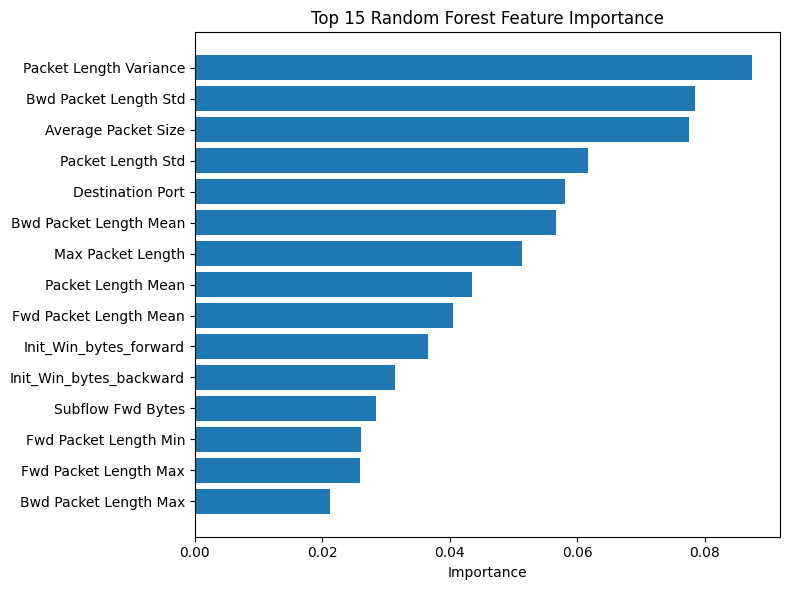

Saved: ..\runs\results\random_forest_full\rf_full_top15_feature_importance.png


In [21]:
#Feature Importance 그래프
plot_importance = top_feature_importance.sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_importance["feature"],
    plot_importance["importance"]
)

plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(RESULTS_DIR / "rf_full_top15_feature_importance.png", dpi=300)
plt.show()

print("Saved:", RESULTS_DIR / "rf_full_top15_feature_importance.png")

In [22]:
#최종 결과 저장
rf_full_test_results.to_csv(
    RESULTS_DIR / "rf_full_test_results.csv",
    index=False
)

pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred
}).to_csv(
    RESULTS_DIR / "rf_full_test_predictions.csv",
    index=False
)

pd.DataFrame(
    rf_full_test_cm,
    index=["Actual_Normal_0", "Actual_Attack_1"],
    columns=["Pred_Normal_0", "Pred_Attack_1"]
).to_csv(
    RESULTS_DIR / "rf_full_test_confusion_matrix.csv",
    index=True
)

rf_full_summary = {
    "model": "Random Forest Full Dataset",
    "train_data": "X_train.csv, y_train.csv",
    "test_data": "X_test.csv, y_test.csv",
    "best_params": best_rf_params,
    "test_result": rf_full_test_result
}

with open(RESULTS_DIR / "rf_full_summary.json", "w", encoding="utf-8") as f:
    json.dump(rf_full_summary, f, indent=4, ensure_ascii=False)

print("Saved final full dataset results.")

Saved final full dataset results.


In [23]:
#저장 파일 확인
saved_files = sorted([p.name for p in RESULTS_DIR.iterdir()])

print("Random Forest full dataset experiment completed.")
print("\nSaved files:")

for file in saved_files:
    print("-", file)

Random Forest full dataset experiment completed.

Saved files:
- rf_full_best_params.json
- rf_full_feature_importance.csv
- rf_full_summary.json
- rf_full_test_confusion_matrix.csv
- rf_full_test_confusion_matrix.png
- rf_full_test_predictions.csv
- rf_full_test_results.csv
- rf_full_top15_feature_importance.png
- 처음 실행 결과
